<a href="https://colab.research.google.com/github/maciekpopik/ENEN-645-Group-4-Final/blob/main/PlantLab2RealGeneralization_CutMix%2BGradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
#Imports

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

In [65]:
#Parameters

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
FEWSHOT_EPOCHS = 5
LR = 3e-4
NUM_WORKERS = 2


In [66]:
#Data transforms (data augmentation + normalization)

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.3, 0.35, 0.4, 0.08),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

In [67]:
#Dataset Paths & Loaders - PlantVillage and PlantDoc dataset

ROOT = "/content/drive/MyDrive/PlantLab2RealGeneralization"

pv_train = datasets.ImageFolder(f"{ROOT}/Train", train_transforms)
pv_val   = datasets.ImageFolder(f"{ROOT}/Val", eval_transforms)
pv_test  = datasets.ImageFolder(f"{ROOT}/Test_ID", eval_transforms)

pd_few   = datasets.ImageFolder(f"{ROOT}/Few_Shot", train_transforms)
pd_test  = datasets.ImageFolder(f"{ROOT}/Test_OOD", eval_transforms)

train_loader = DataLoader(pv_train, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(pv_val, BATCH_SIZE, shuffle=False)
pv_test_loader = DataLoader(pv_test, BATCH_SIZE, shuffle=False)
pd_few_loader  = DataLoader(pd_few, BATCH_SIZE, shuffle=True)
pd_test_loader = DataLoader(pd_test, BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(pv_train.classes)
class_names = pv_train.classes

In [71]:
#Model using EfficientNet

model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.to(DEVICE)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [89]:
#Optimizer and Loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

In [75]:
#CutMix

def cutmix_data(x, y, alpha=1.0):
    x = x.clone()

    lam = np.random.beta(alpha, alpha)
    batch_size, _, H, W = x.size()
    index = torch.randperm(batch_size).to(x.device)

    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_ratio)
    cut_h = int(H * cut_ratio)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]

    lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H))

    return x, y, y[index], lam

In [90]:
def cutmix_loss(pred, y1, y2, lam):
    return lam * criterion(pred, y1) + (1 - lam) * criterion(pred, y2)

In [91]:
#Training and Evaluation

def train_epoch(loader, cutmix=True):
    model.train()
    for x, y in tqdm(loader, leave=False):
        x,y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()

        if cutmix and np.random.rand() < 0.5:
            x,y1,y2,lam = cutmix_data(x,y)
            out = model(x)
            loss = cutmix_loss(out,y1,y2,lam)
        else:
            loss = criterion(model(x), y)

        loss.backward()
        optimizer.step()

In [92]:
def evaluate(loader):
    model.eval()
    correct,total = 0,0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)
    return correct/total

In [79]:
#Training on PlantVillage Dataset

best_val = 0

for e in range(EPOCHS):
    train_epoch(train_loader, cutmix=True)
    val_acc = evaluate(val_loader)
    print(f"Epoch {e+1}: Val Acc {val_acc:.3f}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "best_model.pth")

  0%|          | 0/866 [00:08<?, ?it/s]


KeyboardInterrupt: 

In [80]:
#Best model reload

model.load_state_dict(torch.load("best_model.pth"))

FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pth'

In [81]:
#Test on PlantVillage Test Dataset (Test_ID)

pv_test_acc = evaluate(pv_test_loader)
print(f"PlantVillage Test_ID Accuracy: {pv_test_acc*100:.2f}%")

KeyboardInterrupt: 

In [82]:
#PlantDoc FewShot Dataset Adaptation

for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

for e in range(FEWSHOT_EPOCHS):
    train_epoch(pd_few_loader, cutmix=False)

  0%|          | 0/10 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [83]:
#Final Test on PlantDoc Dataset (Test_OOD)

pd_acc = evaluate(pd_test_loader)
print(f"PlantDoc Accuracy (after few‑shot): {pd_acc*100:.2f}%")

KeyboardInterrupt: 

In [93]:
#GradCAM

class GradCAM:
    def __init__(self, model, layer):
        self.activ = None
        self.grad = None
        layer.register_forward_hook(self._fa)
        layer.register_full_backward_hook(self._fb)

    def _fa(self, m, i, o):
        self.activ = o

    def _fb(self, m, gi, go):
        self.grad = go[0]

    def generate(self):
        w = self.grad.mean((2,3), keepdim=True)
        cam = (w * self.activ).sum(1)
        cam = F.relu(cam)
        return (cam - cam.min()) / (cam.max() + 1e-8)

In [94]:
gradcam = GradCAM(model, model.features[-1])

In [95]:
#GradCAM on PlantVillage vs PlantDoc
# PlantVillage
images, _ = next(iter(pv_test_loader))
img = images[0].unsqueeze(0).to(DEVICE)
img.requires_grad_()
out = model(img)
cls = out.argmax()
model.zero_grad()
out[0, cls].backward()
pv_cam = gradcam.generate()[0].detach().cpu().numpy()

# PlantDoc
images, _ = next(iter(pd_test_loader))
img = images[0].unsqueeze(0).to(DEVICE)
img.requires_grad_()
out = model(img)
cls = out.argmax()
model.zero_grad()
out[0, cls].backward()
pd_cam = gradcam.generate()[0].detach().cpu().numpy()

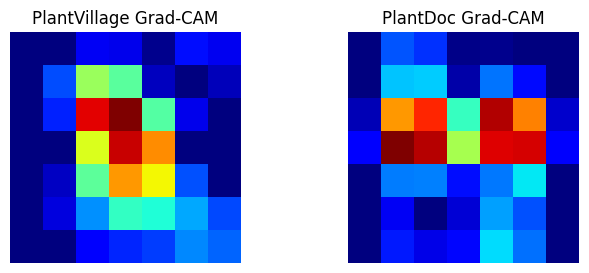

In [96]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.imshow(pv_cam, cmap="jet")
plt.title("PlantVillage Grad‑CAM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pd_cam, cmap="jet")
plt.title("PlantDoc Grad‑CAM")
plt.axis("off")
plt.show()